# Dataset



In [40]:
import pandas as pd

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# Pré-processamento

In [41]:
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df["Amount_log"] = np.log1p(df["Amount"])

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)
print("\nDistribuição no treino:")
print(y_train.value_counts(normalize=True))

Treino: (199364, 31)
Teste: (85443, 31)

Distribuição no treino:
Class
0    0.998275
1    0.001725
Name: proportion, dtype: float64


# Logistic Regression

In [42]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

logistic_pipeline.fit(X_train, y_train)
y_pred_lr = logistic_pipeline.predict(X_test)
y_probs_lr = logistic_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     85295
           1       0.07      0.88      0.12       148

    accuracy                           0.98     85443
   macro avg       0.53      0.93      0.56     85443
weighted avg       1.00      0.98      0.99     85443



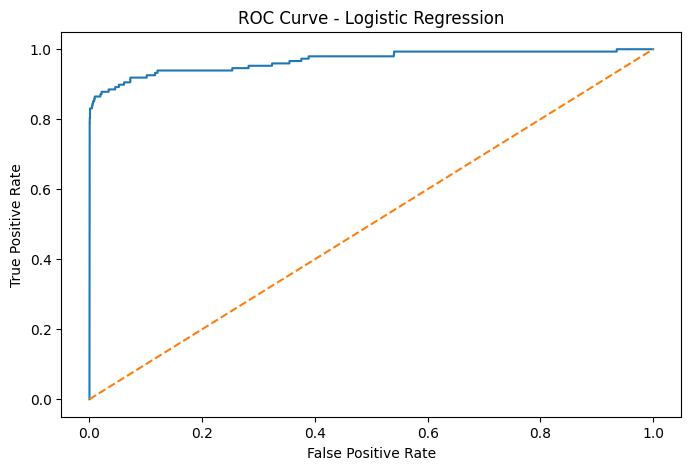

AUC: 0.9677917497777981


In [43]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_probs_lr)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.show()

auc_lr = roc_auc_score(y_test, y_probs_lr)

print("AUC:", auc_lr)

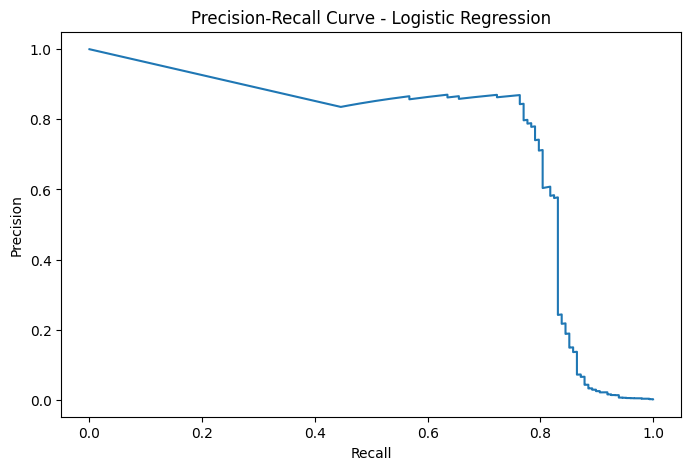

In [44]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds_pr = precision_recall_curve(
    y_test,
    y_probs_lr
)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision)

plt.title("Precision-Recall Curve - Logistic Regression")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.show()

In [45]:
# Undersampling
fraudes = df[df["Class"] == 1]
normais = df[df["Class"] == 0].sample(len(fraudes), random_state=42)

df_under = pd.concat([fraudes, normais])

# Oversampling
from imblearn.over_sampling import SMOTE

smote = SMOTE()

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Antes do SMOTE:")
print(y_train.value_counts())

print("\nDepois do SMOTE:")
print(y_train_smote.value_counts())

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))


Antes do SMOTE:
Class
0    199020
1       344
Name: count, dtype: int64

Depois do SMOTE:
Class
0    199020
1    199020
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.83      0.76      0.80       148

    accuracy                           1.00     85443
   macro avg       0.92      0.88      0.90     85443
weighted avg       1.00      1.00      1.00     85443



In [46]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

threshold = 0.3

y_probs = pipeline.predict_proba(X_test)[:, 1]

y_pred_custom = (y_probs > threshold).astype(int)

print(classification_report(y_test, y_pred_custom))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.80      0.66      0.72       148

    accuracy                           1.00     85443
   macro avg       0.90      0.83      0.86     85443
weighted avg       1.00      1.00      1.00     85443



# XGBoost


In [47]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    scale_pos_weight=10,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_probs_xgb = xgb.predict_proba(X_test)[:, 1]

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))

=== XGBoost ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.93      0.77      0.84       148

    accuracy                           1.00     85443
   macro avg       0.96      0.89      0.92     85443
weighted avg       1.00      1.00      1.00     85443



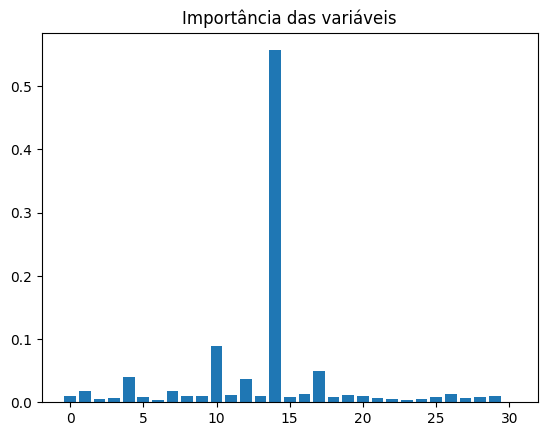

In [48]:
import matplotlib.pyplot as plt

importancias = xgb.feature_importances_

plt.bar(range(len(importancias)), importancias)
plt.title("Importância das variáveis")
plt.show()


In [49]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

param_grid = {
    "max_depth": [3, 5],
    "n_estimators": [50, 100]
}

grid = GridSearchCV(
    XGBClassifier(eval_metric="logloss"),
    param_grid,
    scoring="recall",
    cv=3
)

grid.fit(X_train, y_train)

print("Melhor modelo:", grid.best_params_)

best_xgb = grid.best_estimator_

y_pred_best = best_xgb.predict(X_test)
y_probs_best = best_xgb.predict_proba(X_test)[:, 1]

print("=== Melhor XGBoost ===")
print(classification_report(y_test, y_pred_best))

auc_best = roc_auc_score(y_test, y_probs_best)

print("AUC:", auc_best)


Melhor modelo: {'max_depth': 5, 'n_estimators': 100}
=== Melhor XGBoost ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.72      0.78       148

    accuracy                           1.00     85443
   macro avg       0.92      0.86      0.89     85443
weighted avg       1.00      1.00      1.00     85443

AUC: 0.9133524271090951


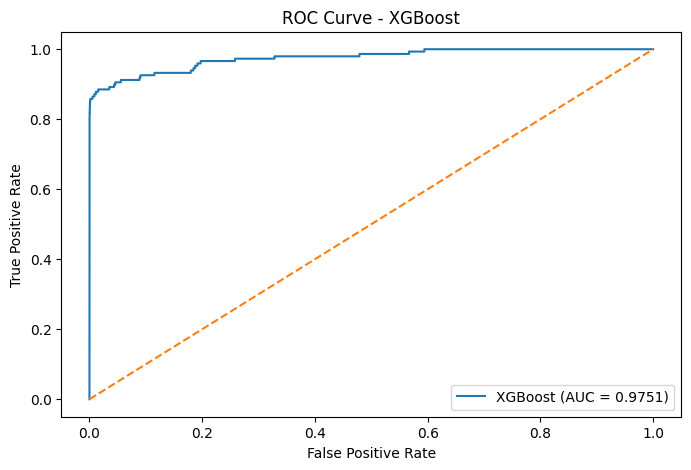

AUC XGBoost: 0.9750678091773701


In [50]:
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_probs_xgb)
auc_xgb = roc_auc_score(y_test, y_probs_xgb)

plt.figure(figsize=(8, 5))

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost (AUC = {auc_xgb:.4f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve - XGBoost")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

print("AUC XGBoost:", auc_xgb)

# Comparação

In [51]:
from sklearn.metrics import precision_score, recall_score, f1_score

resultados = pd.DataFrame({
    "Modelo": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "XGBoost GridSearch"
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_best)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_best)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_best)
    ],
    "AUC": [
        roc_auc_score(y_test, y_probs_lr),
        roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, y_probs_xgb),
        roc_auc_score(y_test, y_probs_best)
    ]
})

resultados

,Modelo,Precision,Recall,F1-Score,AUC
0,Logistic Regression,0.065491,0.878378,0.121894,0.967792
1,Random Forest,0.830882,0.763514,0.795775,0.947432
2,XGBoost,0.926829,0.770270,0.841328,0.975068
3,XGBoost GridSearch,0.835938,0.722973,0.775362,0.913352


# SHAP

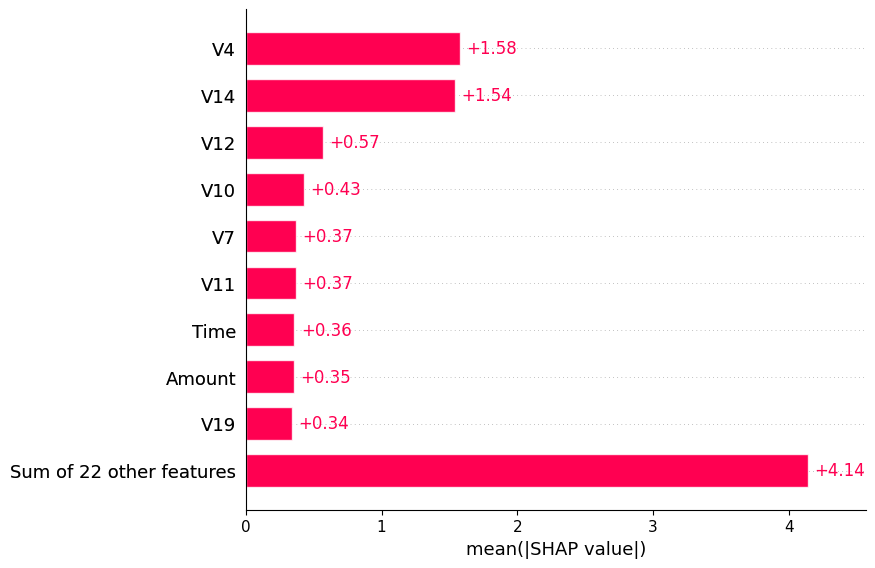

In [52]:
import shap

explainer = shap.TreeExplainer(xgb)

shap_values = explainer(X_test[:100])

shap.plots.bar(shap_values)

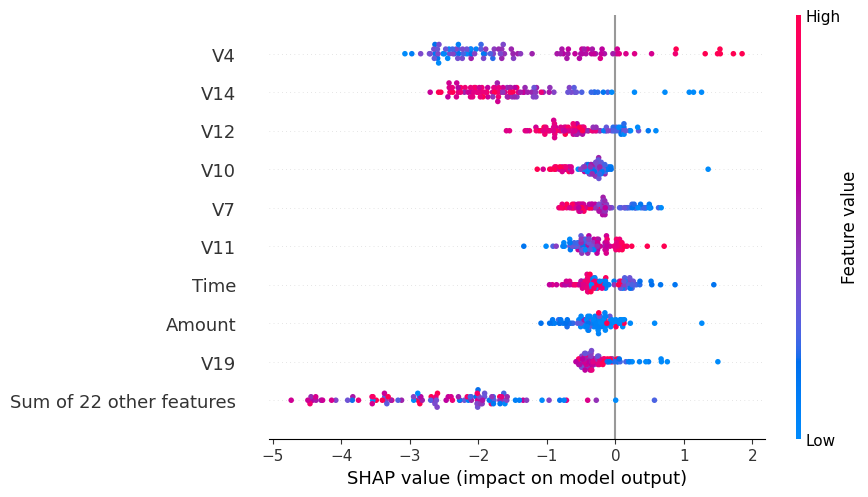

In [53]:
shap.plots.beeswarm(shap_values)